# Preprocessing demo — N2 EEG, notch + canonical-band filtering (C3)

Loads the first 10 subjects found under `$OAK/psg/Bioserenity/edf`, restricts each
subject's `C3` signal to N2-scored epochs (via the hypnodensity hypnogram), then:

1. applies a 60 Hz notch filter and compares the average N2 spectral power
   *before* vs. *after*, and
2. band-passes the notch-filtered signal into six canonical EEG bands
   (Delta, Theta, Alpha, Sigma, Beta, Gamma) and compares the resulting
   average band power,

each step run through **two independent filter implementations** so they can be
compared directly:

* **MNE FIR** — `mne.filter.notch_filter` / `mne.filter.filter_data`
  (`method="fir"`, MNE's own default: linear-phase FIR, zero group delay via
  `phase="zero"`).
* **`infraslow.processing.signal`** — this repo's own `NotchFilter` (IIR,
  `scipy.signal.iirnotch`) and `ButterFilter` (IIR Butterworth), both applied
  zero-phase via `scipy.signal.filtfilt`.

This notebook is exploratory/diagnostic only — nothing here feeds the
production pipeline (`src/group_analysis.py`, `src/run_all_metrics.py`).

Run via Slurm (`sh_dev` / `salloc`), not the login node — loading + filtering
10 subjects is light but still real compute.

In [52]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import mne
import numpy as np
import pandas as pd
import scipy.signal as sp_signal
import yasa
from matplotlib.ticker import NullFormatter, ScalarFormatter

from infraslow import BioserenityPSGLoader
from infraslow.io.utils import list_dir_filenames
from infraslow.processing.infraslow import DEFAULT_SIGMA_BAND
from infraslow.processing.signal import ButterFilter, NotchFilter
from infraslow.processing.spindle import (
    DEFAULT_EPOCH_SEC,
    DEFAULT_STAGE_MAP,
    _extract_epoch_stages,
    _stages_to_int,
)

mne.set_log_level("ERROR")


## 1. Load the first 10 subjects

Lists `$OAK/psg/Bioserenity/edf` with a single `readdir`
(`infraslow.io.utils.list_dir_filenames`) rather than per-file `stat` calls
against the Lustre metadata server, sorts the `.edf` stems, and takes the
first 10.

In [53]:
EDF_DIR = Path(os.environ["OAK"]) / "psg" / "Bioserenity" / "edf"
edf_stems = sorted(Path(n).stem for n in list_dir_filenames(EDF_DIR) if n.endswith(".edf"))
SUBJECT_IDS = edf_stems[:10]
print(f"{len(edf_stems)} EDF(s) found under {EDF_DIR}; using the first 10:")
print(SUBJECT_IDS)

SF = 128.0        # common resample rate (Hz)
CHANNEL = "C3"

loaders = {}
for sid in SUBJECT_IDS:
    try:
        loaders[sid] = BioserenityPSGLoader(
            subject_id=sid, sf=SF, requested_channels=[CHANNEL]
        ).load()
    except Exception as exc:
        print(f"skip {sid}: {exc}")

print(f"\nLoaded {len(loaders)}/{len(SUBJECT_IDS)} subjects: {list(loaders)}")


258448 EDF(s) found under /oak/stanford/groups/mignot/psg/Bioserenity/edf; using the first 10:
['317497', '317947', '318517', '318562', '318619', '318658', '318661', '318667', '318668', '318679']
initiated lunapi 1.4.0 <lunapi.lunapi0.luna object at 0x7f91d6a89030> 



 uniquifying sao2 to sao2.1
___________________________________________________________________
Processing: 317497 | /oak/stanford/groups/mignot/psg/Bioserenity/edf/317497.edf
 duration 08.10.04, 29404s | time 21.47.38 - 05.57.42 | date 01.01.12

 signals: 26 (of 26) selected in an EDF+C file
  C3 | C4 | O1 | O2 | LEOG | REOG | ECGI | emg_CHIN
  emg_RLEG | emg_LLEG | THO | ABD | flow_PFLO | flow_TFLO | flow_CFLO | MICR
  imp | rr | LEAK | IPAP | EPAP | SAO2 | BODY | sao2.1
  HR | EDF Annotations
  extracting 'EDF Annotations' track from EDF+


initiated lunapi 1.4.0 <lunapi.lunapi0.luna object at 0x7f91d6a89030> 



___________________________________________________________________
Processing: 317947 | /oak/stanford/groups/mignot/psg/Bioserenity/edf/317947.edf
 duration 06.17.42, 22662s | time 22.56.39 - 05.14.21 | date 01.01.12

 signals: 29 (of 29) selected in an EDF+C file
  F3 | F4 | C3 | C4 | O1 | O2 | LOC | ROC
  ECG | emg_Chin | emg_RLeg | emg_LLeg | Tho | Abd | SpO2 | flow_PFlo
  flow_TFlo | flow_CFlo | PPG | Snore | imp | rr | Leak | EPAP
  IPAP | Body | sao2 | HR | EDF Annotations
  extracting 'EDF Annotations' track from EDF+


initiated lunapi 1.4.0 <lunapi.lunapi0.luna object at 0x7f91d6a89030> 



...

initiated lunapi 1.4.0 <lunapi.lunapi0.luna object at 0x7f91d6a89030> 



___________________________________________________________________
Processing: 318668 | /oak/stanford/groups/mignot/psg/Bioserenity/edf/318668.edf
 duration 06.02.59, 21779s | time 21.51.09 - 03.54.08 | date 01.01.12

 signals: 26 (of 26) selected in an EDF+C file
  F3 | F4 | C3 | C4 | O1 | O2 | LOC | ROC
  ECG | emg_Chin | emg_RLeg | emg_LLeg | Tho | Abd | SpO2 | flow_PFlo
  flow_TFlo | flow_CFlo | Snore | IPAP | EPAP | Leak | Body | sao2
  HR | EDF Annotations
  extracting 'EDF Annotations' track from EDF+


initiated lunapi 1.4.0 <lunapi.lunapi0.luna object at 0x7f91d6a89030> 



  *** warning, signal 13 ( TFlo ) has a non-integer SR
  *** may wish to use RECORD-SIZE if this is due to a fractional EDF record size
  *** (it will resample signals to fit in a new regular, e.g. dur=1, record size)
    - record size        = 2 seconds
    - samples per record = 25
    - implied SR         = 25 / 2 = 12.5
  *** warning, signal 14 ( CFlo ) has a non-integer SR
  *** may wish to use RECORD-SIZE if this is due to a fractional EDF record size
  *** (it will resample signals to fit in a new regular, e.g. dur=1, record size)
    - record size        = 2 seconds
    - samples per record = 25
    - implied SR         = 25 / 2 = 12.5
  *** warning, signal 15 ( Tho ) has a non-integer SR
  *** may wish to use RECORD-SIZE if this is due to a fractional EDF record size
  *** (it will resample signals to fit in a new regular, e.g. dur=1, record size)
    - record size        = 2 seconds
    - samples per record = 25
    - implied SR         = 25 / 2 = 12.5
  *** warning, signal 1


Loaded 10/10 subjects: ['317497', '317947', '318517', '318562', '318619', '318658', '318661', '318667', '318668', '318679']


## 2. Restrict each subject to N2-scored samples

Upsamples the per-epoch hypnogram to sample resolution (same approach as
`infraslow.processing.spindle.spindles_detect`) and concatenates every N2
sample into one signal per subject. This is a simplification for this demo —
it introduces artificial discontinuities at epoch-run boundaries; a rigorous
analysis would keep N2 bouts separate, the way
`demo_infraslow_yasa_average.ipynb` does.

In [54]:
def n2_signal(loader, channel, *, epoch_sec=DEFAULT_EPOCH_SEC):
    """Concatenated N2-only samples for `channel`, aligned via the hypnogram."""
    stages = _extract_epoch_stages(loader.annotations, stage_column="stage")
    codes = _stages_to_int(stages, DEFAULT_STAGE_MAP)
    sig = loader.get_channel(channel)
    sample_codes = yasa.hypno_upsample_to_data(
        codes, sf_hypno=1.0 / epoch_sec, data=sig, sf_data=loader.sf, verbose=False
    )
    return sig[sample_codes == 2]  # YASA convention: 2 == N2


MIN_N2_SEC = 60.0  # need at least this much N2 to get a stable Welch PSD

n2 = {}
for sid, loader in loaders.items():
    sig = n2_signal(loader, CHANNEL)
    if sig.size < MIN_N2_SEC * SF:
        print(f"skip {sid}: only {sig.size / SF:.0f}s of N2 (< {MIN_N2_SEC:g}s)")
        continue
    n2[sid] = sig.astype(np.float64)

print(f"{len(n2)}/{len(loaders)} subjects have >= {MIN_N2_SEC:g}s of N2 on {CHANNEL}")


22-Jul-26 15:46:18 | WARNING | Hypnogram is SHORTER than data by 4.00 seconds. Padding hypnogram with Unscored (UNS) to match data.size.
22-Jul-26 15:46:18 | WARNING | Hypnogram is SHORTER than data by 12.00 seconds. Padding hypnogram with Unscored (UNS) to match data.size.


22-Jul-26 15:46:18 | WARNING | Hypnogram is SHORTER than data by 17.00 seconds. Padding hypnogram with Unscored (UNS) to match data.size.
22-Jul-26 15:46:18 | WARNING | Hypnogram is SHORTER than data by 16.00 seconds. Padding hypnogram with Unscored (UNS) to match data.size.
22-Jul-26 15:46:18 | WARNING | Hypnogram is SHORTER than data by 6.00 seconds. Padding hypnogram with Unscored (UNS) to match data.size.
22-Jul-26 15:46:18 | WARNING | Hypnogram is SHORTER than data by 17.00 seconds. Padding hypnogram with Unscored (UNS) to match data.size.
22-Jul-26 15:46:18 | WARNING | Hypnogram is SHORTER than data by 28.00 seconds. Padding hypnogram with Unscored (UNS) to match data.size.
22-Jul-26 15:46:18 | WARNING | Hypnogram is SHORTER than data by 17.00 seconds. Padding hypnogram with Unscored (UNS) to match data.size.
22-Jul-26 15:46:18 | WARNING | Hypnogram is SHORTER than data by 29.00 seconds. Padding hypnogram with Unscored (UNS) to match data.size.
22-Jul-26 15:46:18 | WARNING | Hypn

skip 317497: only 0s of N2 (< 60s)
9/10 subjects have >= 60s of N2 on C3


## 3. 60 Hz notch: MNE FIR vs. `infraslow.processing.signal.NotchFilter`

In [55]:
NOTCH_FREQ = 60.0


def mne_notch(sig, sf=SF, freq=NOTCH_FREQ):
    return mne.filter.notch_filter(sig, Fs=sf, freqs=[freq], method="fir", verbose=False)


def custom_notch(sig, sf=SF, freq=NOTCH_FREQ):
    return NotchFilter(sfreq=sf, f0=freq, Q=30.0, filtering="filtfilt")(sig)


def welch_psd(sig, sf=SF, win_sec=4.0):
    nperseg = int(win_sec * sf)
    freqs, psd = sp_signal.welch(sig, fs=sf, nperseg=nperseg, noverlap=nperseg // 2)
    return freqs, psd


mne_notched, custom_notched = {}, {}
raw_psds, mne_psds, custom_psds = [], [], []
freqs_psd = None

for sid, sig in n2.items():
    mne_notched[sid] = mne_notch(sig)
    custom_notched[sid] = custom_notch(sig)

    freqs_psd, p_raw = welch_psd(sig)
    _, p_mne = welch_psd(mne_notched[sid])
    _, p_custom = welch_psd(custom_notched[sid])
    raw_psds.append(p_raw)
    mne_psds.append(p_mne)
    custom_psds.append(p_custom)

raw_mean = np.mean(raw_psds, axis=0)
mne_mean = np.mean(mne_psds, axis=0)
custom_mean = np.mean(custom_psds, axis=0)


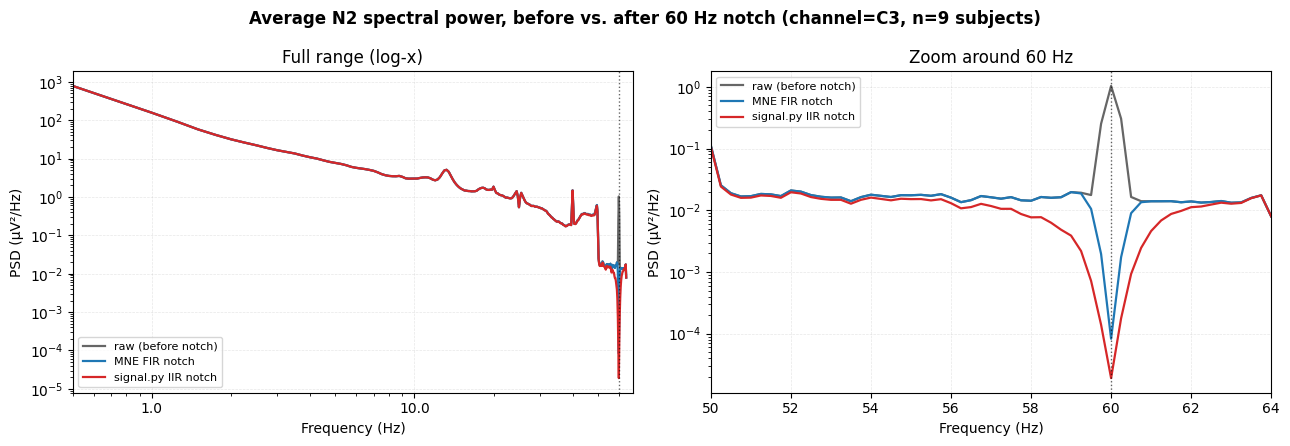

In [56]:
NYQUIST = SF / 2  # 64 Hz for SF=128 -- welch_psd has no content above this

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
panels = [((0.5, 68.0), "Full range (log-x)", True), ((50.0, NYQUIST), "Zoom around 60 Hz", False)]
colors = {"raw": "0.4", "mne": "#1f77b4", "custom": "#d62728"}

for ax, ((lo, hi), title, log_x) in zip(axes, panels):
    m = (freqs_psd >= lo) & (freqs_psd <= hi)
    ax.semilogy(freqs_psd[m], raw_mean[m], color=colors["raw"], lw=1.6, label="raw (before notch)")
    ax.semilogy(freqs_psd[m], mne_mean[m], color=colors["mne"], lw=1.6, label="MNE FIR notch")
    ax.semilogy(freqs_psd[m], custom_mean[m], color=colors["custom"], lw=1.6, label="signal.py IIR notch")
    ax.axvline(NOTCH_FREQ, color="k", ls=":", lw=1, alpha=0.6)
    if log_x:
        # Linear Hz spacing crams Delta/Theta/Alpha into a sliver near 0 and
        # stretches Beta/Gamma across the rest of the axis -- log-x gives every
        # band comparable visual width, the standard convention for wideband
        # EEG PSDs (the narrow 50-Nyquist notch zoom stays linear; log adds
        # nothing over such a narrow window).
        ax.set_xscale("log")
        # ax.set_xticks([0.5, 1, 2, 4, 8, 13, 16, 30, 45])
        ax.xaxis.set_major_formatter(ScalarFormatter())
        ax.xaxis.set_minor_formatter(NullFormatter())
    # Pin the axis to exactly [lo, hi] (no autoscale margin) so the PSD line
    # always reaches both edges instead of stopping short of them.
    ax.set_xlim(lo, hi)
    ax.set_xlabel("Frequency (Hz)")
    ax.set_ylabel("PSD (\u00b5V\u00b2/Hz)")
    ax.set_title(title)
    ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.3)
    ax.legend(fontsize=8)

fig.suptitle(f"Average N2 spectral power, before vs. after 60 Hz notch "
             f"(channel={CHANNEL}, n={len(n2)} subjects)", fontsize=12, fontweight="semibold")
fig.tight_layout()
plt.show()


## 4. Canonical-band power: MNE FIR vs. `infraslow.processing.signal.ButterFilter`

Band-passes each subject's *notch-filtered* N2 signal (each method's own notch
output feeds that same method's band-pass, so both pipelines stay internally
consistent end to end) into six canonical bands, then takes each band-passed
signal's average power (`mean(signal**2)`).

In [57]:
BANDS = {
    "Delta": (0.5, 4.0),
    "Theta": (4.0, 8.0),
    "Alpha": (8.0, 13.0),
    "Sigma": DEFAULT_SIGMA_BAND,   # (11.0, 16.0) -- matches infraslow.processing.infraslow
    "Beta": (13.0, 30.0),
    "Gamma": (30.0, 45.0),
}


def mne_bandpass(sig, low, high, sf=SF):
    return mne.filter.filter_data(sig, sfreq=sf, l_freq=low, h_freq=high, method="fir", verbose=False)


def custom_bandpass(sig, low, high, sf=SF):
    return ButterFilter(sfreq=sf, cutoff=[low, high], mode="band", order=2, filtering="filtfilt")(sig)


rows = []
for sid in n2:
    for band, (lo, hi) in BANDS.items():
        mne_band = mne_bandpass(mne_notched[sid], lo, hi)
        custom_band = custom_bandpass(custom_notched[sid], lo, hi)
        rows.append(dict(subject=sid, band=band, method="MNE FIR", power=float(np.mean(mne_band ** 2))))
        rows.append(dict(subject=sid, band=band, method="signal.py (Butterworth)", power=float(np.mean(custom_band ** 2))))

band_df = pd.DataFrame(rows)
band_summary = band_df.groupby(["band", "method"])["power"].agg(["mean", "sem"]).reset_index()
band_summary


,band,method,mean,sem
0,Alpha,MNE FIR,23.844721,3.003159
1,Alpha,signal.py (Butterworth),13.372487,1.700328
2,Beta,MNE FIR,28.577908,11.323117
3,Beta,signal.py (Butterworth),18.672455,8.352825
4,Delta,MNE FIR,479.611679,318.603363
5,Delta,signal.py (Butterworth),209.200738,109.687745
6,Gamma,MNE FIR,7.919159,3.395754
7,Gamma,signal.py (Butterworth),3.817075,1.474405
8,Sigma,MNE FIR,19.943773,4.237118
9,Sigma,signal.py (Butterworth),12.578338,3.127004


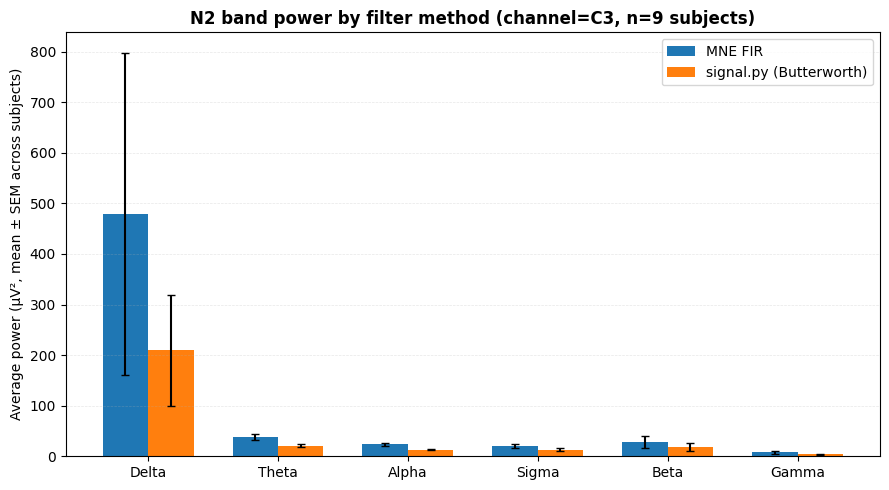

In [58]:
band_order = list(BANDS.keys())
methods = ["MNE FIR", "signal.py (Butterworth)"]
x = np.arange(len(band_order))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
for i, method in enumerate(methods):
    sub = band_summary[band_summary["method"] == method].set_index("band").loc[band_order]
    ax.bar(x + (i - 0.5) * width, sub["mean"], width, yerr=sub["sem"], capsize=3, label=method)

ax.set_xticks(x)
ax.set_xticklabels(band_order)
ax.set_ylabel("Average power (\u00b5V\u00b2, mean \u00b1 SEM across subjects)")
ax.set_title(f"N2 band power by filter method (channel={CHANNEL}, n={len(n2)} subjects)",
             fontsize=12, fontweight="semibold")
ax.grid(True, axis="y", linestyle="--", linewidth=0.5, alpha=0.3)
ax.legend()
fig.tight_layout()
plt.show()


## 5. Time-domain check: one subject, Alpha band

The frequency-domain comparisons above can hide *how* the two filters differ
(FIR linear-phase vs. IIR `filtfilt` zero-phase, transition-band sharpness,
ringing/edge effects). A short raw-vs-filtered snippet makes that visible
directly.

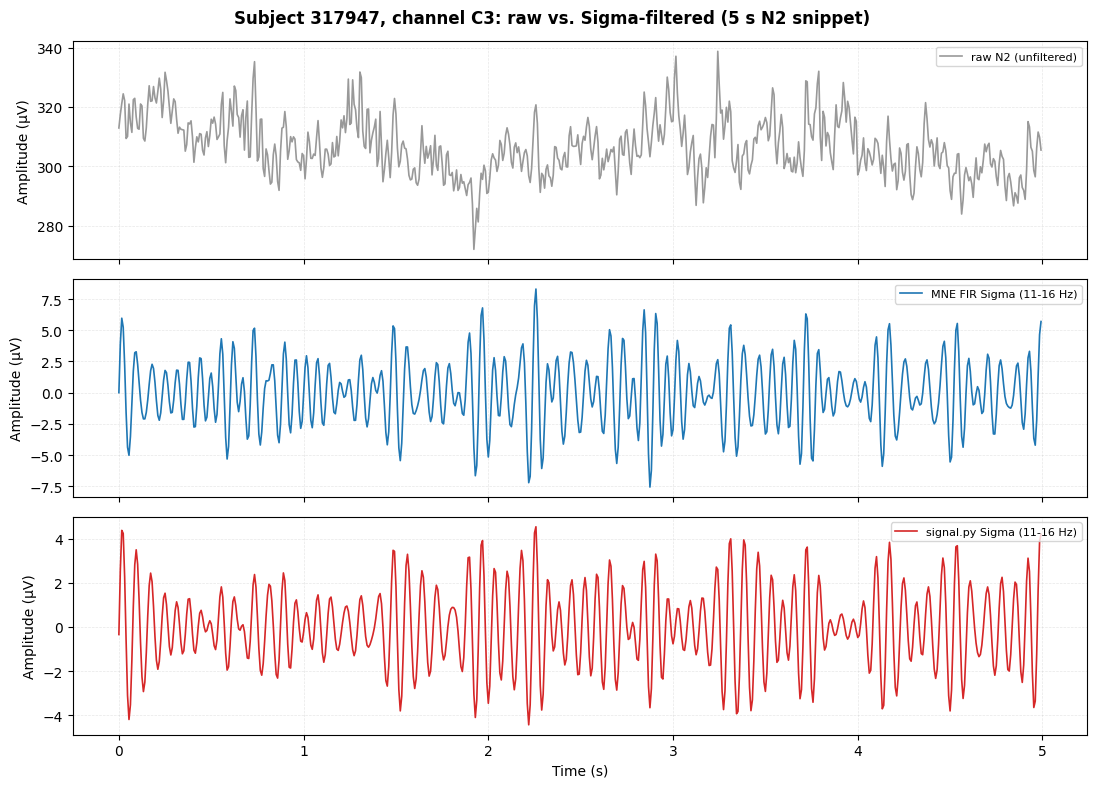

In [62]:
DEMO_SUBJECT = next(iter(n2))
DEMO_BAND = "Sigma"
lo, hi = BANDS[DEMO_BAND]

sig = n2[DEMO_SUBJECT]
mne_band_sig = mne_bandpass(mne_notched[DEMO_SUBJECT], lo, hi)
custom_band_sig = custom_bandpass(custom_notched[DEMO_SUBJECT], lo, hi)

window = slice(0, int(5 * SF))  # first 5 s of this subject's N2 signal
t = np.arange(window.stop) / SF

traces = [
    ("raw N2 (unfiltered)", sig[window], "0.6"),
    (f"MNE FIR {DEMO_BAND} ({lo:g}-{hi:g} Hz)", mne_band_sig[window], "#1f77b4"),
    (f"signal.py {DEMO_BAND} ({lo:g}-{hi:g} Hz)", custom_band_sig[window], "#d62728"),
]

# One subplot per trace (instead of overlaid on one axes) -- raw and the two
# filtered signals otherwise overlap too much to compare directly, especially
# once the filters agree closely.
fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True, sharey=False)
for ax, (label, trace, color) in zip(axes, traces):
    ax.plot(t, trace, color=color, lw=1.2, label=label)
    ax.set_ylabel("Amplitude (\u00b5V)")
    ax.legend(fontsize=8, loc="upper right")
    ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.3)

axes[-1].set_xlabel("Time (s)")
fig.suptitle(f"Subject {DEMO_SUBJECT}, channel {CHANNEL}: raw vs. {DEMO_BAND}-filtered (5 s N2 snippet)",
             fontsize=12, fontweight="semibold")
fig.tight_layout()
plt.show()
